# - 07 k-Nearest Neighbors Classifier 

In this notebook we train and evaluate a k-Nearest Neighbors classifier. 

k-NN predicts a match by looking at the 'k' most similar matches in the training data. Similarity is measured using the distance between their feature values. 

Since k-NN is based directly on distancesm feature scaling is required. We will therefore standardize the numerical features before training the model. 

We use temporal cross-validation to choose: 
- the number of neighbors 'k' 
- wether all neighbors should have the same weight or closer neighbors should have more ifluence 

After choosing the best configuration, we train it on the complete 2015-2022 training set and evaluate it on the external 2023 validation set. 

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

# k-NN uses distances, so numerical features need comparable scales
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier

import sys

# add the project root so that functions from src/ can be imported
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import (
    create_temporal_folds,
    validation_years
)

from src.evaluation import (
    evaluate_model
)

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

### Load the prepared dataset

We start from the dataset created in the previous notebooks, where each match already has its `Training`, `Validation` or `Test` label.

We sort it again by date and MatchID to make sure the chronological order is preserved.

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

# Date is loaded directly as datetime since the temporal split
# and cross-validation depend on match dates
matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

# keep all matches in chronological order
matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


### Recover the chronological splits

The split was already defined in the data-splitting notebook.

Here we simply create separate DataFrames for training, validation and test data so that we can use them during model development.

In [3]:
# create separate copies of the three datasets
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

# check the date range of every split
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [4]:
# training must finish before validation starts
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

# validation must finish before the final test period starts
assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


### Model features 

We use the same numerical and categorical feature lists defined in `preprocessing.py`.

This is important because we want all classification models in the project to start from the same information, making their results easier to compare.

In [5]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)


Numerical features: 30
Categorical features: 5
Raw features: 35


### Temporal cross-validation

We use the same expanding-window temporal cross-validation defined in the previous notebook.

The model is always trained on earlier years and validated on a later year. This avoids training a model using information from matches that happened after the matches used for validation.

The four folds use 2019, 2020, 2021 and 2022 as validation years.

In [6]:
# create temporal cross-validation folds using only the training period
temporal_folds= create_temporal_folds(
    train_data,
    validation_years = validation_years
)

print(
    "Number of temporal folds created:", 
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds created: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


## k-NN configurations to test

The main hyperparameter of k-NN is `k`, which represents how many neighboring observations are considered when making a prediction.

A very small `k` can make the model too sensitive to individual training examples, while a larger `k` produces a snoother and more stable decision. 

We also compare two weighting strategies: 
- `uniform`: every neighbor has the same influence 
- `distance`: closer neighbors have more influence than distant ones

We test several values of `k` instead of choosing one manually. 

In [7]:
# different values of k and weighting methods that are compared
configurations = [
    {
        "name": "kNN k=11",
        "n_neighbors": 11,
        "weights": "uniform"
    },

    {
        "name": "kNN k=31",
        "n_neighbors": 31,
        "weights": "uniform"
    },

    {
        "name": "kNN k=51",
        "n_neighbors": 51,
        "weights": "uniform"
    },

    {
        "name": "kNN k=75",
        "n_neighbors": 75,
        "weights": "uniform"
    },

    {
        "name": "kNN k=101",
        "n_neighbors": 101,
        "weights": "uniform"
    },

    {
        "name": "kNN k=151",
        "n_neighbors": 151,
        "weights": "uniform"
    },

    {
        "name": "kNN k=11 distance",
        "n_neighbors": 11,
        "weights": "distance"
    },

    {
        "name": "kNN k=31 distance",
        "n_neighbors": 31,
        "weights": "distance"
    },

    {
        "name": "kNN k=51 distance",
        "n_neighbors": 51,
        "weights": "distance"
    },

    {
        "name": "kNN k=75 distance",
        "n_neighbors": 75,
        "weights": "distance"
    },

    {
        "name": "kNN k=101 distance",
        "n_neighbors": 101,
        "weights": "distance"
    },

    {
        "name": "kNN k=151 distance",
        "n_neighbors": 151,
        "weights": "distance"
    }
]

In [8]:
print(
    "Configurations to test:",
    len(configurations)
)

Configurations to test: 12


### Run every configuration on every temporal fold

We have 12 k-NN configurations and 4 temporal folds, so the tuning procedure will run: 
**12 x 4 = 48 experiments**

For every experiment, we process and scale the data using only that fold's training period, train the k-NN model and evaluate it on the corresponding validation year. 

The results are stored so that we can later calculate the avarage performance of each configuration. 

In [9]:
# store the evaluation result of every configuration and every fold
knn_cv_results = [] 

for configuration in configurations:
    print("Testing:",configuration["name"])

    for fold in temporal_folds:
        fold_number = (fold["Fold"])
        validation_year = (fold["ValidationYear"])

        # use all years before the current validation year for training
        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()

        # use the current year as the validation period
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()

        # fit preprocessing only on the training part of this fold
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor (
            fold_train
        )

        # apply the same preprocessing to training and validation
        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        # Player1Won = 1 -> Player 1 won
        # Player1Won = 0 -> Player 2 won
        y_fold_train = (fold_train["Player1Won"].to_numpy())
        y_fold_validation = (fold_validation["Player1Won"].to_numpy())

        # k-NN uses distances, so numerical features must be scaled
        fold_scaler = StandardScaler()

        # learn mean and standard deviation from training data only
        X_fold_train[numeric_features] = fold_scaler.fit_transform(
            X_fold_train[numeric_features]
        )

        # apply the same scaling to validation data
        X_fold_validation[numeric_features] = fold_scaler.transform(
            X_fold_validation[numeric_features]
        )

        # create the current k-NN configuration
        current_model = KNeighborsClassifier(
            n_neighbors = configuration["n_neighbors"],
            weights = configuration["weights"],
            n_jobs = -1
        )

        # k-NN stores the training observations that will later
        # be used to find the nearest neighbors
        current_model.fit(
            X_fold_train,
            y_fold_train
        )

        # predicted winner for every validation match
        current_predictions = (
            current_model.predict(X_fold_validation)
        )

        # probability assigned to Player 1 winning
        current_probabilities = (
            current_model.predict_proba(X_fold_validation)[:, 1]
        )

        # calculate all evaluation metrics for this fold
        current_fold_results = (
            evaluate_model(
                y_true = y_fold_validation,
                y_pred = current_predictions,
                model_name = configuration["name"],
                y_probability = current_probabilities
            )
        )

        # evaluate_model returns one-row DataFrame;
        # convert that row to a dictionary so extra information can be added
        current_fold_result = (
            current_fold_results.iloc[0].to_dict()
        )

        current_fold_result["Fold"] = fold_number
        current_fold_result["ValidationYear"] = validation_year
        current_fold_result["Neighbors"] = configuration["n_neighbors"]
        current_fold_result["Weights"] = configuration["weights"]

        # save this experiment
        knn_cv_results.append(current_fold_result)

        print(
            "Fold", 
            fold_number,
            "year",
            validation_year,
            "accuracy:",
            round(current_fold_result["Accuracy"], 4)
        )

print(
    "\nTotal results collected:",
    len(knn_cv_results)
)

Testing: kNN k=11
Fold 1 year 2019 accuracy: 0.6127
Fold 2 year 2020 accuracy: 0.6117
Fold 3 year 2021 accuracy: 0.5966
Fold 4 year 2022 accuracy: 0.6181
Testing: kNN k=31
Fold 1 year 2019 accuracy: 0.6187
Fold 2 year 2020 accuracy: 0.6296
Fold 3 year 2021 accuracy: 0.6162
Fold 4 year 2022 accuracy: 0.6436
Testing: kNN k=51
Fold 1 year 2019 accuracy: 0.6223
Fold 2 year 2020 accuracy: 0.6304
Fold 3 year 2021 accuracy: 0.6216
Fold 4 year 2022 accuracy: 0.6475
Testing: kNN k=75
Fold 1 year 2019 accuracy: 0.6243
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6241
Fold 4 year 2022 accuracy: 0.6503
Testing: kNN k=101
Fold 1 year 2019 accuracy: 0.6223
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6153
Fold 4 year 2022 accuracy: 0.6582
Testing: kNN k=151
Fold 1 year 2019 accuracy: 0.6284
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6261
Fold 4 year 2022 accuracy: 0.6621
Testing: kNN k=11 distance
Fold 1 year 2019 accuracy: 0.6123
Fold 2 year 2020

### First observations

The cross-validation results suggest that very small values of `k` perform worse.

Performance generally improves as more neighbors are considered, and the best mean accuracy is obtained with **k = 151 and uniform weights**.

The difference between uniform and distance weighting is relatively small, especially for the larger values of `k`.

This suggests that using more neighbors makes the predictions more stable for this dataset.

In [10]:
# convert results into a dataframe

knn_cv_fold_results = pd.DataFrame(knn_cv_results)

print("Configurations: ", len(configurations))
print("Temporal folds: ", len(temporal_folds))
print("Results: ", len(knn_cv_fold_results))

Configurations:  12
Temporal folds:  4
Results:  48


In [11]:
# 12 configurations x 4 folds should produce 48 results
assert(len(knn_cv_fold_results) == len(configurations) * len(temporal_folds))

In [12]:
knn_cv_fold_results.head()

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,Neighbors,Weights
0,kNN k=11,0.612735,0.612758,0.608140,0.615509,0.611802,0.646124,0.744988,1,2019,11,uniform
1,kNN k=11,0.611698,0.612311,0.633943,0.596244,0.614516,0.651575,0.806380,2,2020,11,uniform
2,kNN k=11,0.596586,0.596524,0.577441,0.594970,0.586074,0.634320,0.834791,3,2021,11,uniform
3,kNN k=11,0.618075,0.617911,0.620861,0.593354,0.606796,0.664639,0.709379,4,2022,11,uniform
4,kNN k=31,0.618742,0.618567,0.619765,0.597738,0.608553,0.664799,0.648397,1,2019,31,uniform


### Summarize the temporal cross-validation results

Each configuration has four results, one from each temporal fold.

We now group them by configuration and calculate the average performance across the four years.

We also calculate the standard deviation of accuracy to get an idea of how stable the performance is across different validation periods. Two models could have the same average accuracy, but one may perform very differently across years. Standard deviation gives us an indication of how stable the model is across folds.

In [13]:
# average the results of each configuration across the four temporal folds
knn_cv_summary = (
    knn_cv_fold_results.groupby(
        ["Model", "Neighbors", "Weights"],
        as_index = False
    ).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
    )
)

In [14]:
# rank configurations mainly by mean accuracy
# ROC-AUC is used as a second criterion if accuracies are equal
knn_cv_summary = (
    knn_cv_summary.sort_values(
        by = ["MeanAccuracy", "MeanROC_AUC"],
        ascending = [False, False]
    ).reset_index(drop = True)
)

In [15]:
knn_cv_summary

,Model,Neighbors,Weights,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,kNN k=151,151,uniform,0.637147,0.016798,0.637157,0.625480,0.693629,0.631763
1,kNN k=151 distance,151,distance,0.635204,0.017568,0.635197,0.623547,0.693853,0.631453
2,kNN k=75,75,uniform,0.632678,0.012307,0.632568,0.622035,0.690567,0.632155
3,kNN k=101,101,uniform,0.631957,0.018756,0.631867,0.619810,0.692153,0.631652
4,kNN k=101 distance,101,distance,0.631648,0.018610,0.631522,0.619144,0.692285,0.631514
5,kNN k=51 distance,51,distance,0.631345,0.012961,0.631229,0.620011,0.684281,0.635971
6,kNN k=75 distance,75,distance,0.630641,0.014309,0.630421,0.619795,0.690533,0.632165
7,kNN k=51,51,uniform,0.630460,0.012067,0.630342,0.619509,0.684188,0.636056
8,kNN k=31 distance,31,distance,0.628053,0.012085,0.628173,0.618140,0.675764,0.641913
9,kNN k=31,31,uniform,0.627020,0.012497,0.627075,0.616762,0.675614,0.641879


### Select the best configuration

The configurations are already ordered by their mean temporal-CV accuracy, so the first row represents the selected k-NN configuration.

We then recover its original hyperparameter settings from the configuration list, so they can be used to build the final validation model.

In [16]:
# name of the configuration with the best temporal-CV performance 
best_model_name = (knn_cv_summary.iloc[0]["Model"])

# recover its k and weighting method
best_configuration = next(
    configuration
    for configuration in configurations
    if configuration["name"] == best_model_name
)

print("Selected k-NN:", best_model_name)

best_configuration

Selected k-NN: kNN k=151


{'name': 'kNN k=151', 'n_neighbors': 151, 'weights': 'uniform'}

## Train the selected k-NN on the complete training set

Hyperparameter selection is now finished.

The best configuration from temporal cross-validation is **k = 151 with uniform weights**.

We can now use the complete 2015-2022 training period to fit the model that will be evaluated on the external 2023 validation set.

In [17]:
# fit preprocessing once on the complete 2015-2022 training set
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

# transform training and external validation using the same preprocessing
X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# target values
y_train = (train_data["Player1Won"].to_numpy())
y_validation = (validation_data["Player1Won"].to_numpy())

In [18]:
print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)

Training X: (18810, 50)
Validation X: (2607, 50)


In [19]:
# preprocessing should leave no missing values
assert (X_train.isna().sum().sum() == 0)
assert (X_validation.isna().sum().sum() == 0)

# training and validation must contain exactly the same features
assert list(X_train.columns) == list(X_validation.columns)

### Scale the numerical features

Before fitting k-NN, we standardize the numerical variables.

The scaler is fitted only on the training data. The same mean and standard deviation are then used to transform the 2023 validation data.

In [20]:
knn_scaler = StandardScaler()

# learn scaling parameters from training data and transform it
X_train[numeric_features] = knn_scaler.fit_transform(
    X_train[numeric_features]
)

# apply the same transformation to validation data
X_validation[numeric_features] = knn_scaler.transform(
    X_validation[numeric_features]
)

print("k-NN scaling completed")

k-NN scaling completed


### Fit the selected model 

We now build the k-NN classifier using the hyperparameters selected through temporal cross-validation and fit it on all available training matches from 2015-2022.

In [21]:
# build the k-NN model using the selected hyperparameters
best_knn = KNeighborsClassifier( # build the best knn
    n_neighbors = best_configuration["n_neighbors"],
    weights = best_configuration["weights"],
    n_jobs = -1
)

# fit the model on the complete training set
best_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",151
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Evaluate on the 2023 validation set 

We now use the selected model to predict the external validation matches. 

We calculate bith:
- the predicted class, meaning which player is expected to win 
- the probability assigned to player 1 winning

The probabilities are needed for metrics such as ROC-AUC and LogLoss.

In [22]:
# predicted winner: 0 = Player 2, 1 = Player 1
best_validation_predictions = (
    best_knn.predict(X_validation)
) 

# probability assigned to Player 1 winning
best_validation_probabilities = (
    best_knn.predict_proba(X_validation)[:, 1]
)

# show precision, recall and F1 for both possible match outcomes
print(
    classification_report(
        y_validation,
        best_validation_predictions,
        target_names = ["Player 2 wins", "Player 1 wins"],
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.66      0.66      1368
Player 1 wins       0.63      0.63      0.63      1239

     accuracy                           0.65      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.65      0.65      0.65      2607



In [23]:
# calculate the same metrics used for the other project models
best_knn_result = evaluate_model(
    y_true = y_validation,
    y_pred = (best_validation_predictions),
    model_name = (best_model_name),
    y_probability = (best_validation_probabilities)
)

best_knn_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,kNN k=151,0.645186,0.644448,0.626003,0.62954,0.627767,0.700511,0.627929


The selected k-NN reaches an accuracy of approximately **64.5%** on the 2023 validation set, with a ROC-AUC of approximately **0.70**.

This is clearly better than random guessing, but its performance still needs to be compared with the other machine-learning models and with the simple tennis baselines before deciding whether it is a good final model.

### Confusion matrix

The confusion matrix shows how many Player 1 and Player 2 wins were classified correctly or incorrectly.

This helps check whether the total accuracy is hiding a strong preference for one of the two classes.

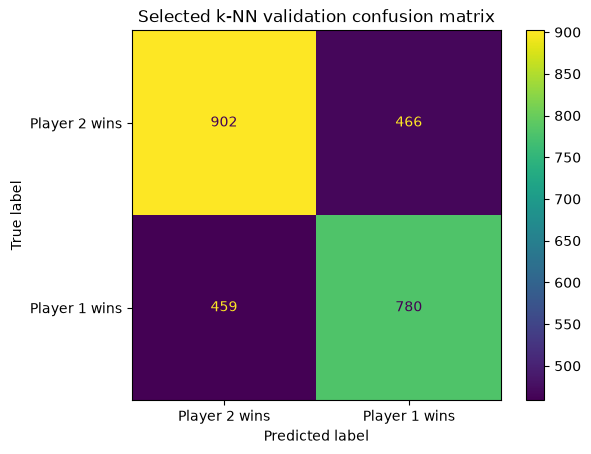

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    display_labels = ["Player 2 wins", "Player 1 wins"],
    values_format = "d"
)

plt.title("Selected k-NN validation confusion matrix")
plt.show()

### Effect of the number of neighbors

To better understand the tuning results, we decided to plot mean temporal-CV accuracy against the number of neighbors.

The two lines compare uniform and distance-based weighting.

This allows us to see how the choice of `k` affects performance instead of looking only at the final selected configuration.

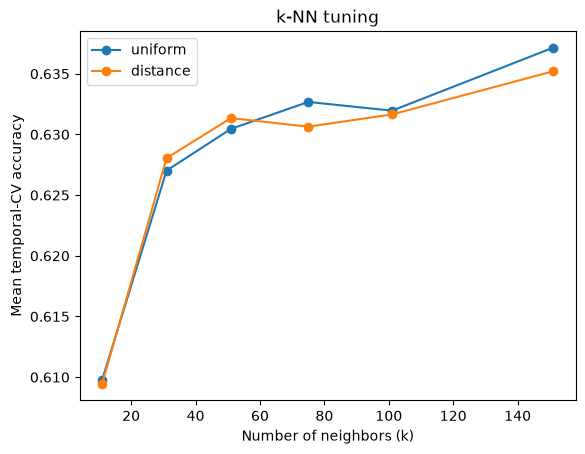

In [25]:
for weight_type in["uniform", "distance"]:
    
    # select all configurations using the current weighting method
    plot_data = (
        knn_cv_summary.loc[
            knn_cv_summary["Weights"] == weight_type
        ].sort_values("Neighbors")
    )

    plt.plot(
        plot_data["Neighbors"],
        plot_data["MeanAccuracy"],
        marker = "o",
        label = weight_type
    )

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean temporal-CV accuracy")
plt.title("k-NN tuning")
plt.legend()
plt.show()

The graph shows that the smallest values of `k` perform worse, while accuracy generally improves when more neighbors are considered.

The best mean temporal-CV accuracy is obtained with **151 neighbors and uniform weighting**.

Uniform and distance weighting give very similar results for most values of `k`, suggesting that weighting closer neighbors more strongly does not provide a clear advantage in this case.

## Save model-selection and validation results

Finally, we save both the individual temporal-CV results and their summary so they can be inspected later.

We also save the external validation result of the selected k-NN model for comparison with the other classifiers.

In [ ]:
MODEL_SELECTION_RESULTS_DIR = Path(
    "../results/model_selection"
)

VALIDATION_RESULTS_DIR = Path(
    "../results/validation"
)

MODELS_DIR = Path("../models")

# individual result for every configuration/fold combination
knn_cv_fold_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR / "knn_cv_fold_results.csv",
    index = False
)

# average performance of every tested configuration
knn_cv_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR / "knn_cv_tuning_summary.csv",
    index = False
)

# performance of the selected model on 2023 validation data
best_knn_result.to_csv(
    VALIDATION_RESULTS_DIR / "best_knn_result.csv",
    index=False
)

### Save the fitted model and scaler

We save both the selected k-NN classifier and its fitted scaler.

The scaler is needed together with the model because any future data must be transformed using exactly the same means and standard deviations that were learned from the training data.

In [27]:
import joblib

# save the fitted classifier
joblib.dump(
    best_knn,
    MODELS_DIR / "best_knn_validation.joblib"
)

# save the scaler used by the classifier
joblib.dump(
    knn_scaler,
    MODELS_DIR / "best_knn_scaler.joblib"
)

['..\\models\\best_knn_scaler.joblib']

In [28]:
print("k-NN TEMPORAL CV")
print(knn_cv_summary)

print("\nSelected configuration:", best_model_name)

print("\nExternal 2023 validation")
print(best_knn_result)

k-NN TEMPORAL CV
                 Model  Neighbors   Weights  MeanAccuracy  StdAccuracy  \
0            kNN k=151        151   uniform      0.637147     0.016798   
1   kNN k=151 distance        151  distance      0.635204     0.017568   
2             kNN k=75         75   uniform      0.632678     0.012307   
3            kNN k=101        101   uniform      0.631957     0.018756   
4   kNN k=101 distance        101  distance      0.631648     0.018610   
5    kNN k=51 distance         51  distance      0.631345     0.012961   
6    kNN k=75 distance         75  distance      0.630641     0.014309   
7             kNN k=51         51   uniform      0.630460     0.012067   
8    kNN k=31 distance         31  distance      0.628053     0.012085   
9             kNN k=31         31   uniform      0.627020     0.012497   
10            kNN k=11         11   uniform      0.609773     0.009225   
11   kNN k=11 distance         11  distance      0.609462     0.010451   

    MeanBalancedAccu

## Conclusion

Temporal cross-validation selected a k-NN model with **151 neighbors and uniform weights**.

The selected model achieved about **64.5% accuracy** and **0.70 ROC-AUC** on the external 2023 validation set.

The results show that k-NN is able to capture useful relationships between similar tennis matches, although its performance is only moderately above the simple baselines. Its final usefulness will therefore depend on how it compares with the other classifiers tested in the project.